<a href="https://colab.research.google.com/github/YodahJ/Fake-drug-checker/blob/main/My-Capstone-project-colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Welcome to Colab!

To access files stored in your Google Drive, you first need to mount your Drive to this Colab notebook. This will prompt you to authenticate your Google account.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Accessing Data from Google Drive

To access files stored in your Google Drive, you first need to mount your Drive to this Colab notebook. This will prompt you to authenticate your Google account.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

# Google Sheet URL provided by the user
google_sheet_url = 'https://docs.google.com/spreadsheets/d/1ovTAGEMaOUVhAysIpbHDBwArpVTHy_B5/edit?usp=drivesdk&ouid=110514581705796177328&rtpof=true&sd=true'

# Convert the Google Sheet URL to an exportable CSV URL
# IMPORTANT: This assumes the sheet is publicly accessible or shared with 'Anyone with the link can view'.
# To make your sheet public, go to 'Share' -> 'Get link' -> 'Change to anyone with the link' -> 'Viewer'.
csv_export_url = google_sheet_url.replace('/edit?usp=drivesdk&ouid=110514581705796177328&rtpof=true&sd=true', '/export?format=csv')

try:
    # Load the CSV data directly into a pandas DataFrame
    df_google_sheet = pd.read_csv(csv_export_url)
    print('Successfully loaded data from Google Sheet.')

    # Display the first 5 rows of the DataFrame
    display(df_google_sheet.head())
except Exception as e:
    print(f'An error occurred while loading the Google Sheet data: {e}')

An error occurred while loading the Google Sheet data: HTTP Error 401: Unauthorized


In [6]:
# Install the gspread library
!pip install gspread

In [7]:
import pandas as pd

In [8]:
import gspread
from google.colab import auth
from google.auth import default # Import default for getting authenticated credentials
import pandas as pd # Re-inserted pandas import directly here to ensure availability

# Authenticate Google Colab for gspread
auth.authenticate_user()

# Get the credentials from the authenticated user
creds, _ = default()

# Authorize gspread client with these credentials
gc = gspread.Client(auth=creds);

# Google Sheet URL provided by the user
google_sheet_url = 'https://docs.google.com/spreadsheets/d/10j5Z355NcIHKMxTyaS_hZcCMQcF-bEbsUXyOFI_pOnE/edit?usp=drivesdk'

try:
    # Open the spreadsheet by its URL
    # IMPORTANT: Ensure the Google Sheet is shared with the Google account you authenticated with.
    # For private sheets, you might need to share it with the email address displayed during the authentication process.
    workbook = gc.open_by_url(google_sheet_url);

    # Select the first worksheet (you can change this if your data is on another sheet)
    worksheet = workbook.sheet1;

    # Get all values from the worksheet as a list of lists
    rows = worksheet.get_all_values();

    # Convert to pandas DataFrame
    # The first row is assumed to be the header
    df_gspread = pd.DataFrame(rows[1:], columns=rows[0]);

    print('Successfully loaded data from Google Sheet using gspread.')
    display(df_gspread.head())
except Exception as e:
    print(f'An error occurred while loading the Google Sheet data with gspread: {e}')

Successfully loaded data from Google Sheet using gspread.


,"""S/N"";","""SAMPLE CODE"" ;","""LABORATORY NUMBER"" ;","""STATE"" ;","""BRAND NAME""",;,"""GENERIC NAME"" ;","""PRODUCT CLASS"" ;","""NAFDAC REG.","NO"";",...,,,,,,,,,;,"""YEAR CAPTURED"""
0,"""1"" ;","""ABI/ADG/001/211123"" ;","""KLS/AB/PMS/DCN/0025/24"" ;","""ABIA"" ;","""MEPIRYL""",;,"""GLIMEPIRIDE"" ...","""ANTIDIABETIC"" ;","""04-9439""",;,...,,,,,,,,,;,"""2023"""
1,"""2"" ;","""ABI/ADG/002/211123"" ;","""KLS/AB/PMS/DCN/0026/24"" ;","""ABIA"" ;","""AMARYL""",;,"""GLIMEPIRIDE"" ...","""ANTIDIABETIC"" ;","""04-2852""",;,...,,,,,,,,,;,"""2023"""
2,"""3"" ;","""ABI/ADG/003/221123"" ;","""KLS/AB/PMS/DCN/0027/24"" ;","""ABIA"" ;","""MEPIRYL""",;,"""GLIMEPIRIDE"" ...","""ANTIDIABETIC"" ;","""04-9605""",;,...,,,,,,,,,;,"""2023"""
3,"""4"" ;","""ABI/ADG/004/221123"" ;","""KLS/AB/PMS/DCN/0028/24"" ;","""ABIA"" ;","""MEPIRYL""",;,"""GLIMEPIRIDE"" ...","""ANTIDIABETIC"" ;","""04-9605""",;,...,,,,,,,,,;,"""2023"""
4,"""5"" ;","""ABI/ADG/005/231123"" ;","""KLS/AB/PMS/DCN/0029/24"" ;","""ABIA"" ;","""GETRYL""",;,"""GLIMEPIRIDE"" ...","""ANTIDIABETIC"" ;","""A4-8747""",;,...,,,,,,,,,;,"""2023"""


In [9]:
import numpy as np

print(f"Shape of DataFrame before cleaning and dropping null rows: {df_gspread.shape}")

# --- Step 1: Clean column names ---
# Remove quotes and semicolons from column names, then strip whitespace
df_gspread.columns = [col.replace('"', '').replace(';', '').strip() for col in df_gspread.columns]

# --- Step 2: Clean data values ---
# Apply a lambda function to each element to clean string values
# Remove quotes, semicolons, strip whitespace, then replace truly empty strings with np.nan
df_gspread = df_gspread.map(lambda x: str(x).replace('"', '').replace(';', '').strip() if isinstance(x, str) else x) # Ensure it's a string before calling replace
df_gspread = df_gspread.replace('', np.nan)

print(f"Shape of DataFrame after cleaning strings (before dropping): {df_gspread.shape}")

# --- Step 3: Remove rows where all values are NaN (now correctly identified) ---
df_gspread_cleaned = df_gspread.dropna(how='all')

print(f"Shape of DataFrame after dropping null rows: {df_gspread_cleaned.shape}")
display(df_gspread_cleaned.head())

Shape of DataFrame before cleaning and dropping null rows: (822, 43)
Shape of DataFrame after cleaning strings (before dropping): (822, 43)
Shape of DataFrame after dropping null rows: (822, 43)


/tmp/ipykernel_1763/2354856621.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_gspread = df_gspread.replace('', np.nan)


,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,...,,,,,,,,,,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,NaN,GLIMEPIRIDE,ANTIDIABETIC,04-9439,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,NaN,GLIMEPIRIDE,ANTIDIABETIC,04-2852,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,NaN,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,NaN,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,NaN,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023


## Summary Statistics of Cleaned DataFrame

In [10]:
print('--- DataFrame Info ---')
df_gspread_cleaned.info()

print('\n--- Descriptive Statistics ---')
display(df_gspread_cleaned.describe(include='all'))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   S/N                                  819 non-null    object 
 1   SAMPLE CODE                          817 non-null    object 
 2   LABORATORY NUMBER                    763 non-null    object 
 3   STATE                                794 non-null    object 
 4   BRAND NAME                           817 non-null    object 
 5                                        0 non-null      float64
 6   GENERIC NAME                         817 non-null    object 
 7   PRODUCT CLASS                        817 non-null    object 
 8   NAFDAC REG.                          815 non-null    object 
 9   NO                                   1 non-null      object 
 10  DOSAGE FORM                          816 non-null    object 
 11  STRENGTH 

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,...,,,,,,,,,,YEAR CAPTURED
count,819,817,763,794,817,0.0,817,817,815,1,...,1,1,1,1,1,1,1,1,1,817
unique,306,769,605,32,311,NaN,183,6,198,1,...,1,1,1,1,1,1,1,1,1,5
top,21,-,NIL,ABIA,MEPIRYL,NaN,ARTEMETHER + LUMENFANTRINE,ANTI-MALARIA,NIL,NO,...,does,not,meets,the,specification,for,Uniformity,of,weight,2023
freq,8,23,137,74,28,NaN,151,268,253,1,...,1,1,1,1,1,1,1,1,1,392
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Dropping Uninformative Columns

In [11]:
# Identify columns with empty string names
empty_name_columns = [col for col in df_gspread_cleaned.columns if col == '']

print(f"Columns to be dropped: {empty_name_columns}")

# Drop these columns from the DataFrame
df_gspread_cleaned = df_gspread_cleaned.drop(columns=empty_name_columns, errors='ignore') # Use errors='ignore' in case some columns are already dropped or not found

print(f"Shape of DataFrame after dropping uninformative columns: {df_gspread_cleaned.shape}")
display(df_gspread_cleaned.head())

Columns to be dropped: ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
Shape of DataFrame after dropping uninformative columns: (822, 26)


,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,DOSAGE FORM,...,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,SPECIFICATION,COMMENT,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NIL,NIL,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,NaN,TABLET,...,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NIL,NIL,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NIL,NIL,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NIL,NIL,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,NaN,TABLET,...,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",NIL,NIL,PASS,2023


## Converting 'nan' and 'NIL' Strings to Actual Null Values

In [12]:
import numpy as np

# Define the list of string values to be treated as NaN
missing_value_strings = ['nan', 'NIL', '-']

# Replace these strings with actual np.nan values across the entire DataFrame
df_gspread_cleaned = df_gspread_cleaned.replace(missing_value_strings, np.nan)

print("DataFrame info after replacing 'nan' and 'NIL' strings with np.nan:")
df_gspread_cleaned.info()

print('\nFirst 5 rows after replacing missing value strings:')
display(df_gspread_cleaned.head())

DataFrame info after replacing 'nan' and 'NIL' strings with np.nan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  819 non-null    object
 1   SAMPLE CODE                          794 non-null    object
 2   LABORATORY NUMBER                    603 non-null    object
 3   STATE                                794 non-null    object
 4   BRAND NAME                           817 non-null    object
 5   GENERIC NAME                         817 non-null    object
 6   PRODUCT CLASS                        817 non-null    object
 7   NAFDAC REG.                          562 non-null    object
 8   NO                                   1 non-null      object
 9   DOSAGE FORM                          816 non-null    object
 10  STRENGTH                             740 n

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,DOSAGE FORM,...,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,SPECIFICATION,COMMENT,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NaN,NaN,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,NaN,TABLET,...,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NaN,NaN,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NaN,NaN,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NaN,NaN,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,NaN,TABLET,...,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",NaN,NaN,PASS,2023


## Identifying and Dropping Columns with High Percentage of Null Values

In [13]:
# Calculate the percentage of null values for each column
null_percentages = df_gspread_cleaned.isnull().sum() / len(df_gspread_cleaned) * 100

# Display columns with their null percentages, sorted descending
print('Percentage of Null Values per Column (sorted descending):')
display(null_percentages.sort_values(ascending=False))

# Define a threshold for dropping columns (e.g., 70% nulls)
null_threshold = 70
columns_to_drop_by_nulls = null_percentages[null_percentages > null_threshold].index.tolist()

print(f"\nColumns to be dropped (>{null_threshold}% nulls): {columns_to_drop_by_nulls}")

# Drop these columns
df_gspread_cleaned = df_gspread_cleaned.drop(columns=columns_to_drop_by_nulls, errors='ignore') # Use errors='ignore' in case some columns are already dropped or not found

print(f"\nShape of DataFrame after dropping high-null columns: {df_gspread_cleaned.shape}")
print('\nDataFrame Info after dropping columns:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after dropping high-null columns:')
display(df_gspread_cleaned.head())

Percentage of Null Values per Column (sorted descending):


,0
NO,99.878345
COMMENT,83.090024
SPECIFICATION,72.262774
PHYSICAL DESCRIPTION,47.566910
MANUFACTURER ADDRESS,44.890511
MARKET AUTHORISATION HOLDER ADDRESS,39.416058
QTY SAMPLED,33.819951
NAFDAC REG.,31.630170
MANUF. DATE,31.386861
PACK SIZE,31.021898



Columns to be dropped (>70% nulls): ['NO', 'SPECIFICATION', 'COMMENT']

Shape of DataFrame after dropping high-null columns: (822, 23)

DataFrame Info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  819 non-null    object
 1   SAMPLE CODE                          794 non-null    object
 2   LABORATORY NUMBER                    603 non-null    object
 3   STATE                                794 non-null    object
 4   BRAND NAME                           817 non-null    object
 5   GENERIC NAME                         817 non-null    object
 6   PRODUCT CLASS                        817 non-null    object
 7   NAFDAC REG.                          562 non-null    object
 8   DOSAGE FORM                          816 non-null    object
 9  

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4MG,...,01/2026,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4MG,...,10/2025,3 PACKS,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,08/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,12/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4MG,...,05/2026,3 PACKS,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023


## Dropping Rows with Any Remaining Null Values

In [14]:
print(f"Shape of DataFrame before dropping rows with any nulls: {df_gspread_cleaned.shape}")

# Drop rows that contain any null values
df_gspread_cleaned = df_gspread_cleaned.dropna(how='any')

print(f"Shape of DataFrame after dropping rows with any nulls: {df_gspread_cleaned.shape}")

print('\nDataFrame Info after dropping rows:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after dropping all nulls:')
display(df_gspread_cleaned.head())

Shape of DataFrame before dropping rows with any nulls: (822, 23)
Shape of DataFrame after dropping rows with any nulls: (212, 23)

DataFrame Info after dropping rows:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  212 non-null    object
 1   SAMPLE CODE                          212 non-null    object
 2   LABORATORY NUMBER                    212 non-null    object
 3   STATE                                212 non-null    object
 4   BRAND NAME                           212 non-null    object
 5   GENERIC NAME                         212 non-null    object
 6   PRODUCT CLASS                        212 non-null    object
 7   NAFDAC REG.                          212 non-null    object
 8   DOSAGE FORM                          212 non-null    object
 9   STRENGTH    

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4MG,...,01/2026,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4MG,...,10/2025,3 PACKS,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,08/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,12/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4MG,...,05/2026,3 PACKS,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023


## Converting Columns to Numeric Types

In [15]:
import numpy as np
import re

# List of columns to attempt converting to numeric
columns_to_numeric = [
    'S/N',
    'STRENGTH',
    'PACK SIZE',
    'QTY SAMPLED',
    'YEAR CAPTURED'
]

for col in columns_to_numeric:
    if col in df_gspread_cleaned.columns:
        if col == 'STRENGTH' or col == 'PACK SIZE' or col == 'QTY SAMPLED':
            # Extract numbers from strings using regex for specific columns (if they exist)
            print(f"Cleaning and attempting to extract numbers from '{col}' for numeric conversion.")
            extracted_numbers = df_gspread_cleaned[col].astype(str).str.extract('(\\d+\\.?\\d*)', expand=False)
            df_gspread_cleaned[col] = pd.to_numeric(extracted_numbers, errors='coerce')
        else:
            # Attempt to convert to numeric, coercing errors to NaN
            print(f"Attempting to convert '{col}' to numeric.")
            df_gspread_cleaned[col] = pd.to_numeric(df_gspread_cleaned[col], errors='coerce')
    else:
        print(f"Column '{col}' not found in DataFrame, skipping conversion.")

print('\nDataFrame Info after numeric conversions:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after numeric conversions:')
display(df_gspread_cleaned.head())

Attempting to convert 'S/N' to numeric.
Cleaning and attempting to extract numbers from 'STRENGTH' for numeric conversion.
Cleaning and attempting to extract numbers from 'PACK SIZE' for numeric conversion.
Cleaning and attempting to extract numbers from 'QTY SAMPLED' for numeric conversion.
Attempting to convert 'YEAR CAPTURED' to numeric.

DataFrame Info after numeric conversions:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   S/N                                  212 non-null    int64  
 1   SAMPLE CODE                          212 non-null    object 
 2   LABORATORY NUMBER                    212 non-null    object 
 3   STATE                                212 non-null    object 
 4   BRAND NAME                           212 non-null    object 
 5   GENERIC NAME                         212 non-nu

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4.0,...,01/2026,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4.0,...,10/2025,3.0,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,08/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,12/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4.0,...,05/2026,3.0,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023.0


## Converting Remaining Columns to Categorical Types

In [16]:
# List of columns to convert to categorical type
columns_to_categorical = [
    'STRENGTH',
    'PACK SIZE',
    'QTY SAMPLED'
]

for col in columns_to_categorical:
    if col in df_gspread_cleaned.columns:
        # Ensure the column is not all NaN from failed numeric conversion before converting to category
        if df_gspread_cleaned[col].isnull().all():
            print(f"Column '{col}' is all NaN after numeric extraction, will convert to category as requested.")
            # If it's all NaN, it means numeric extraction failed, convert the original object column to category
            df_gspread_cleaned[col] = df_gspread_cleaned[col].astype('category')
        else:
            print(f"Converted '{col}' to categorical type.")
            df_gspread_cleaned[col] = df_gspread_cleaned[col].astype('category')
    else:
        print(f"Column '{col}' not found in DataFrame, skipping categorical conversion.")

print('\nDataFrame Info after categorical conversions:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after categorical conversions:')
display(df_gspread_cleaned.head())

Converted 'STRENGTH' to categorical type.
Converted 'PACK SIZE' to categorical type.
Converted 'QTY SAMPLED' to categorical type.

DataFrame Info after categorical conversions:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   S/N                                  212 non-null    int64   
 1   SAMPLE CODE                          212 non-null    object  
 2   LABORATORY NUMBER                    212 non-null    object  
 3   STATE                                212 non-null    object  
 4   BRAND NAME                           212 non-null    object  
 5   GENERIC NAME                         212 non-null    object  
 6   PRODUCT CLASS                        212 non-null    object  
 7   NAFDAC REG.                          212 non-null    object  
 8   DOSAGE FORM                          212 non-nul

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4.0,...,01/2026,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4.0,...,10/2025,3.0,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,08/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,12/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4.0,...,05/2026,3.0,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023.0


## Summary Statistics of Final Cleaned DataFrame

In [17]:
print('--- DataFrame Info ---')
df_gspread_cleaned.info()

print('\n--- Descriptive Statistics ---')
display(df_gspread_cleaned.describe(include='all'))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   S/N                                  212 non-null    int64   
 1   SAMPLE CODE                          212 non-null    object  
 2   LABORATORY NUMBER                    212 non-null    object  
 3   STATE                                212 non-null    object  
 4   BRAND NAME                           212 non-null    object  
 5   GENERIC NAME                         212 non-null    object  
 6   PRODUCT CLASS                        212 non-null    object  
 7   NAFDAC REG.                          212 non-null    object  
 8   DOSAGE FORM                          212 non-null    object  
 9   STRENGTH                             211 non-null    category
 10  PACK SIZE                            211 non-null    category
 11  B

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
count,212.000000,212,212,212,212,212,212,212,212,211.0,...,212,211.0,212,212,212,212,212,212,212,211.0
unique,NaN,212,212,26,52,3,3,51,2,2.0,...,107,6.0,48,51,38,41,8,16,3,NaN
top,NaN,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,LAGOS,MEPIRYL,AMLODIPINE,ANTIHYPERTENSIVE,04-9439,TABLET,10.0,...,06/2026,5.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",INDIA,TABLET IN BLISTER STRIPS IN LABELLED HARDBOARD...,PASS,NaN
freq,NaN,1,1,21,28,141,141,19,211,141.0,...,14,114.0,29,29,29,29,113,184,210,NaN
mean,63.183962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0
std,42.462017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0
25%,27.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0
50%,56.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0
75%,95.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023.0


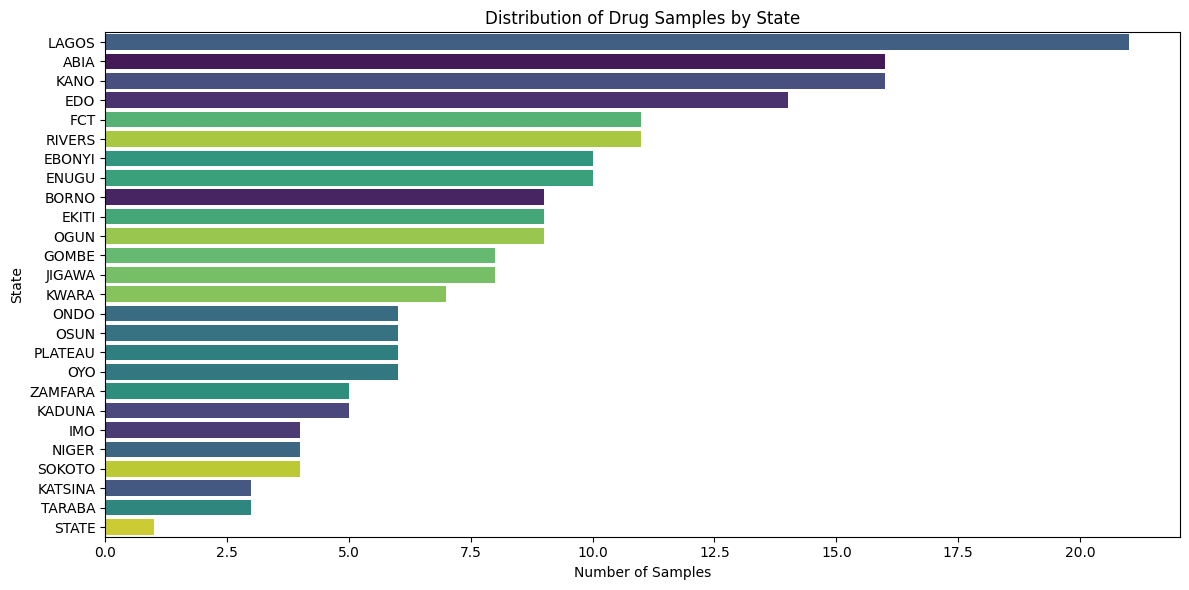

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(y='STATE', data=df_gspread_cleaned, order=df_gspread_cleaned['STATE'].value_counts().index, palette='viridis', hue='STATE', legend=False)
plt.title('Distribution of Drug Samples by State')
plt.xlabel('Number of Samples')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Distribution of Product Class

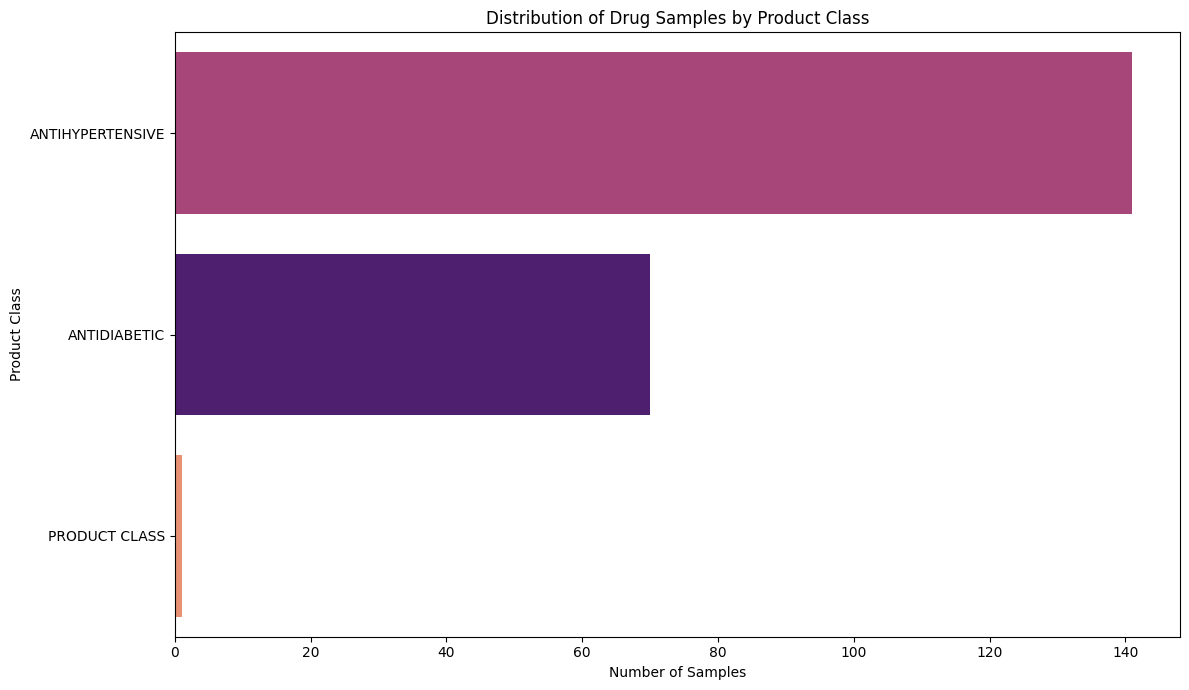

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='PRODUCT CLASS', data=df_gspread_cleaned,
              order=df_gspread_cleaned['PRODUCT CLASS'].value_counts().index,
              palette='magma', hue='PRODUCT CLASS', legend=False)
plt.title('Distribution of Drug Samples by Product Class')
plt.xlabel('Number of Samples')
plt.ylabel('Product Class')
plt.tight_layout()
plt.show()

## Distribution of Generic Name

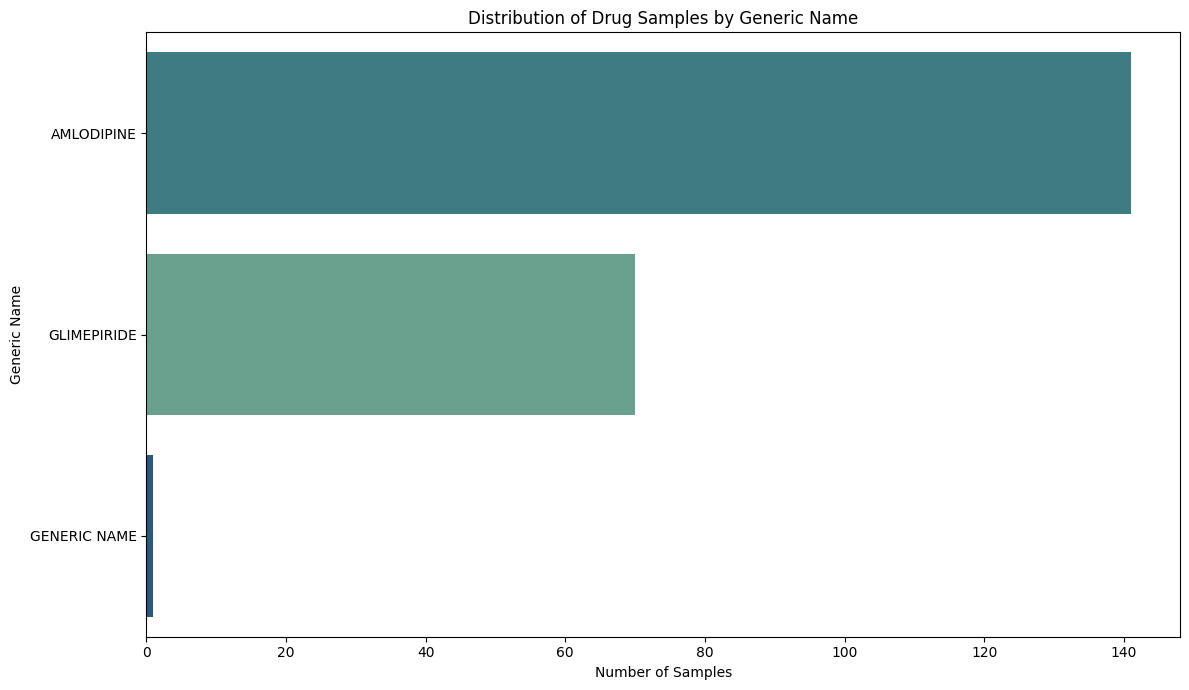

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.countplot(y='GENERIC NAME', data=df_gspread_cleaned,
              order=df_gspread_cleaned['GENERIC NAME'].value_counts().index,
              palette='crest', hue='GENERIC NAME', legend=False)
plt.title('Distribution of Drug Samples by Generic Name')
plt.xlabel('Number of Samples')
plt.ylabel('Generic Name')
plt.tight_layout()
plt.show()

## Analyzing the Relationship between 'PRODUCT CLASS' and 'REMARKS'

First, let's look at the unique values and their counts for the 'REMARKS' column to understand its content and distribution.

In [21]:
print('Value Counts for REMARKS:')
display(df_gspread_cleaned['REMARKS'].value_counts())

Value Counts for REMARKS:


,count
REMARKS,
PASS,210
FAIL,1
REMARKS,1


Given the distribution of remarks, we can now visualize the relationship between 'PRODUCT CLASS' and 'REMARKS'. Since there are multiple unique remarks, a grouped bar chart showing the count of each remark within each product class will be insightful. However, if there are too many unique 'REMARKS', we might need to focus on the top N remarks or use a different aggregation.

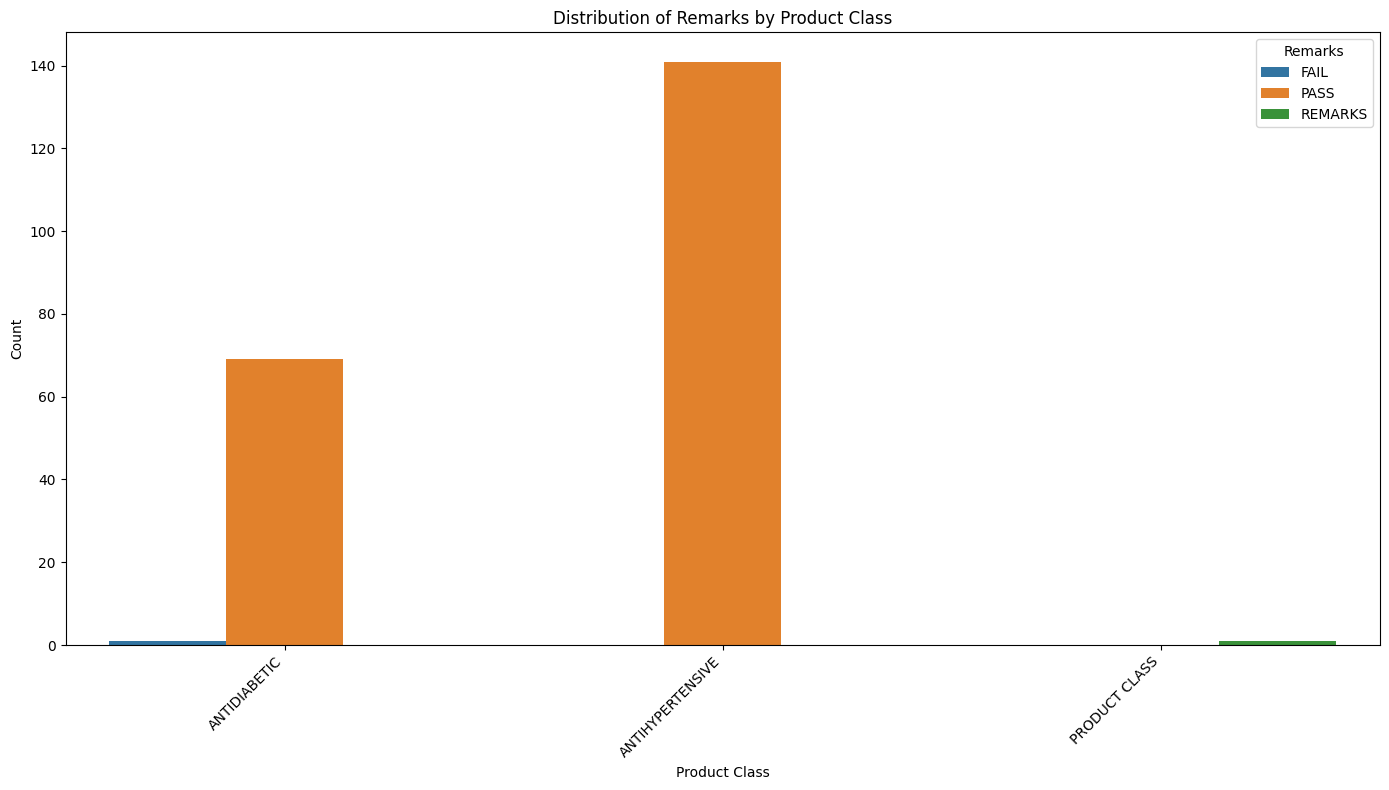

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a cross-tabulation to count occurrences of each remark per product class
remark_product_class_counts = df_gspread_cleaned.groupby(['PRODUCT CLASS', 'REMARKS']).size().unstack(fill_value=0)

# For better visualization, we might want to plot the top N remarks if there are too many unique remarks.
# For now, let's consider a melt operation to prepare for a grouped bar chart.
# If remark_product_class_counts has too many columns, this might be unreadable.

# Let's pivot the table for easier plotting if 'REMARKS' has few unique values, or stack if many.
# For demonstration, we'll melt and plot if the number of unique remarks is manageable.

if remark_product_class_counts.shape[1] <= 10: # Heuristic: if <= 10 unique remarks, plot directly
    df_plot = remark_product_class_counts.reset_index().melt(id_vars='PRODUCT CLASS', var_name='Remark', value_name='Count')
    plt.figure(figsize=(14, 8))
    sns.barplot(x='PRODUCT CLASS', y='Count', hue='Remark', data=df_plot)
    plt.title('Distribution of Remarks by Product Class')
    plt.xlabel('Product Class')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Remarks')
    plt.tight_layout()
    plt.show()
else:
    print("There are too many unique 'REMARKS' to display effectively in a single grouped bar chart.")
    print("Consider focusing on the top N remarks or analyzing the cross-tabulation directly.")
    display(remark_product_class_counts)

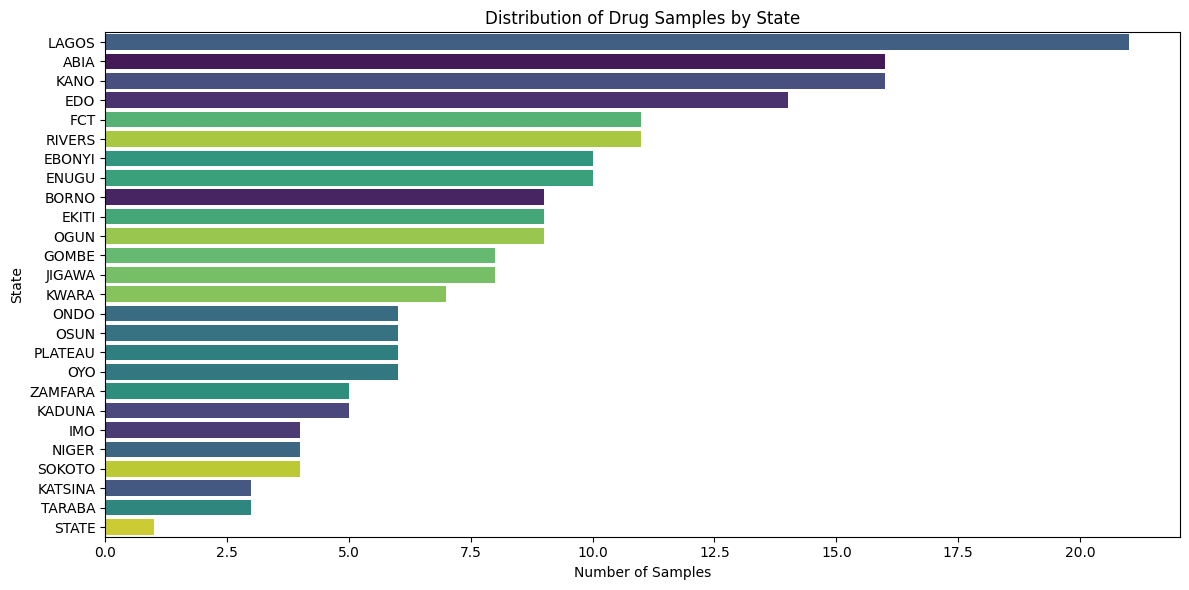

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(y='STATE', data=df_gspread_cleaned, order=df_gspread_cleaned['STATE'].value_counts().index, palette='viridis', hue='STATE', legend=False)
plt.title('Distribution of Drug Samples by State')
plt.xlabel('Number of Samples')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [24]:
import numpy as np

print(f"Shape of DataFrame before cleaning and dropping null rows: {df_gspread.shape}")

# --- Step 1: Clean column names ---
# Remove quotes and semicolons from column names, then strip whitespace
df_gspread.columns = [col.replace('"', '').replace(';', '').strip() for col in df_gspread.columns]

# --- Step 2: Clean data values ---
# Apply a lambda function to each element to clean string values
# Remove quotes, semicolons, strip whitespace, then replace truly empty strings with np.nan
df_gspread = df_gspread.map(lambda x: str(x).replace('"', '').replace(';', '').strip()) # Changed applymap to map
df_gspread = df_gspread.replace('', np.nan)

print(f"Shape of DataFrame after cleaning strings (before dropping): {df_gspread.shape}")

# --- Step 3: Remove rows where all values are NaN (now correctly identified) ---
df_gspread_cleaned = df_gspread.dropna(how='all')

print(f"Shape of DataFrame after dropping null rows: {df_gspread_cleaned.shape}")
display(df_gspread_cleaned.head())

Shape of DataFrame before cleaning and dropping null rows: (822, 43)
Shape of DataFrame after cleaning strings (before dropping): (822, 43)
Shape of DataFrame after dropping null rows: (822, 43)


,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,...,,,,,,,,,,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,nan,GLIMEPIRIDE,ANTIDIABETIC,04-9439,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,nan,GLIMEPIRIDE,ANTIDIABETIC,04-2852,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,nan,GLIMEPIRIDE,ANTIDIABETIC,04-9605,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,nan,GLIMEPIRIDE,ANTIDIABETIC,04-9605,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,nan,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023


## Summary Statistics of Cleaned DataFrame

In [25]:
print('--- DataFrame Info ---')
df_gspread_cleaned.info()

print('\n--- Descriptive Statistics ---')
display(df_gspread_cleaned.describe(include='all'))

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 43 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  822 non-null    object
 1   SAMPLE CODE                          822 non-null    object
 2   LABORATORY NUMBER                    822 non-null    object
 3   STATE                                822 non-null    object
 4   BRAND NAME                           822 non-null    object
 5                                        822 non-null    object
 6   GENERIC NAME                         822 non-null    object
 7   PRODUCT CLASS                        822 non-null    object
 8   NAFDAC REG.                          822 non-null    object
 9   NO                                   822 non-null    object
 10  DOSAGE FORM                          822 non-null    object
 11  STRENGTH              

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,...,,,,,,,,,,YEAR CAPTURED
count,822,822,822,822,822,822,822,822,822,822,...,822,822,822,822,822,822,822,822,822,822
unique,307,770,606,33,312,1,184,7,199,2,...,2,2,2,2,2,2,2,2,2,6
top,20,-,NIL,ABIA,MEPIRYL,nan,ARTEMETHER + LUMENFANTRINE,ANTI-MALARIA,NIL,nan,...,nan,nan,nan,nan,nan,nan,nan,nan,nan,2023
freq,8,23,137,74,28,822,151,268,253,821,...,821,821,821,821,821,821,821,821,821,392


## Dropping Uninformative Columns

In [26]:
# Identify columns with empty string names
empty_name_columns = [col for col in df_gspread_cleaned.columns if col == '']

print(f"Columns to be dropped: {empty_name_columns}")

# Drop these columns from the DataFrame
df_gspread_cleaned = df_gspread_cleaned.drop(columns=empty_name_columns)

print(f"Shape of DataFrame after dropping uninformative columns: {df_gspread_cleaned.shape}")
display(df_gspread_cleaned.head())

Columns to be dropped: ['', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '', '']
Shape of DataFrame after dropping uninformative columns: (822, 26)


,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,DOSAGE FORM,...,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,SPECIFICATION,COMMENT,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,nan,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NIL,NIL,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,nan,TABLET,...,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NIL,NIL,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,nan,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NIL,NIL,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,nan,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NIL,NIL,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,nan,TABLET,...,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",NIL,NIL,PASS,2023


## Converting 'nan' and 'NIL' Strings to Actual Null Values

In [27]:
import numpy as np

# Define the list of string values to be treated as NaN
missing_value_strings = ['nan', 'NIL', '-']

# Replace these strings with actual np.nan values across the entire DataFrame
df_gspread_cleaned = df_gspread_cleaned.replace(missing_value_strings, np.nan)

print("DataFrame info after replacing 'nan' and 'NIL' strings with np.nan:")
df_gspread_cleaned.info()

print('\nFirst 5 rows after replacing missing value strings:')
display(df_gspread_cleaned.head())

DataFrame info after replacing 'nan' and 'NIL' strings with np.nan:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 26 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  819 non-null    object
 1   SAMPLE CODE                          794 non-null    object
 2   LABORATORY NUMBER                    603 non-null    object
 3   STATE                                794 non-null    object
 4   BRAND NAME                           817 non-null    object
 5   GENERIC NAME                         817 non-null    object
 6   PRODUCT CLASS                        817 non-null    object
 7   NAFDAC REG.                          562 non-null    object
 8   NO                                   1 non-null      object
 9   DOSAGE FORM                          816 non-null    object
 10  STRENGTH                             740 n

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,NO,DOSAGE FORM,...,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,SPECIFICATION,COMMENT,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NaN,NaN,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,NaN,TABLET,...,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,NaN,NaN,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NaN,NaN,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,NaN,TABLET,...,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,NaN,NaN,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,NaN,TABLET,...,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",NaN,NaN,PASS,2023


## Identifying and Dropping Columns with High Percentage of Null Values

In [28]:
# Calculate the percentage of null values for each column
null_percentages = df_gspread_cleaned.isnull().sum() / len(df_gspread_cleaned) * 100

# Display columns with their null percentages, sorted descending
print('Percentage of Null Values per Column (sorted descending):')
display(null_percentages.sort_values(ascending=False))

# Define a threshold for dropping columns (e.g., 70% nulls)
null_threshold = 70
columns_to_drop_by_nulls = null_percentages[null_percentages > null_threshold].index.tolist()

print(f"\nColumns to be dropped (>{null_threshold}% nulls): {columns_to_drop_by_nulls}")

# Drop these columns
df_gspread_cleaned = df_gspread_cleaned.drop(columns=columns_to_drop_by_nulls)

print(f"\nShape of DataFrame after dropping high-null columns: {df_gspread_cleaned.shape}")
print('\nDataFrame Info after dropping columns:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after dropping high-null columns:')
display(df_gspread_cleaned.head())

Percentage of Null Values per Column (sorted descending):


,0
NO,99.878345
COMMENT,83.090024
SPECIFICATION,72.262774
PHYSICAL DESCRIPTION,47.566910
MANUFACTURER ADDRESS,44.890511
MARKET AUTHORISATION HOLDER ADDRESS,39.416058
QTY SAMPLED,33.819951
NAFDAC REG.,31.630170
MANUF. DATE,31.386861
PACK SIZE,31.021898



Columns to be dropped (>70% nulls): ['NO', 'SPECIFICATION', 'COMMENT']

Shape of DataFrame after dropping high-null columns: (822, 23)

DataFrame Info after dropping columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 822 entries, 0 to 821
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  819 non-null    object
 1   SAMPLE CODE                          794 non-null    object
 2   LABORATORY NUMBER                    603 non-null    object
 3   STATE                                794 non-null    object
 4   BRAND NAME                           817 non-null    object
 5   GENERIC NAME                         817 non-null    object
 6   PRODUCT CLASS                        817 non-null    object
 7   NAFDAC REG.                          562 non-null    object
 8   DOSAGE FORM                          816 non-null    object
 9  

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4MG,...,01/2026,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4MG,...,10/2025,3 PACKS,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,08/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,12/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4MG,...,05/2026,3 PACKS,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023


## Dropping Rows with Any Remaining Null Values

In [29]:
print(f"Shape of DataFrame before dropping rows with any nulls: {df_gspread_cleaned.shape}")

# Drop rows that contain any null values
df_gspread_cleaned = df_gspread_cleaned.dropna(how='any')

print(f"Shape of DataFrame after dropping rows with any nulls: {df_gspread_cleaned.shape}")

print('\nDataFrame Info after dropping rows:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after dropping all nulls:')
display(df_gspread_cleaned.head())

Shape of DataFrame before dropping rows with any nulls: (822, 23)
Shape of DataFrame after dropping rows with any nulls: (212, 23)

DataFrame Info after dropping rows:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   S/N                                  212 non-null    object
 1   SAMPLE CODE                          212 non-null    object
 2   LABORATORY NUMBER                    212 non-null    object
 3   STATE                                212 non-null    object
 4   BRAND NAME                           212 non-null    object
 5   GENERIC NAME                         212 non-null    object
 6   PRODUCT CLASS                        212 non-null    object
 7   NAFDAC REG.                          212 non-null    object
 8   DOSAGE FORM                          212 non-null    object
 9   STRENGTH    

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4MG,...,01/2026,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4MG,...,10/2025,3 PACKS,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,08/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4MG,...,12/2025,3 PACKS,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4MG,...,05/2026,3 PACKS,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023


## Converting Columns to Numeric Types

In [30]:
import numpy as np
import re

# List of columns to attempt converting to numeric
columns_to_numeric = [
    'S/N',
    'STRENGTH',
    'PACK SIZE',
    'QTY SAMPLED',
    'YEAR CAPTURED'
]

for col in columns_to_numeric:
    if col in df_gspread_cleaned.columns:
        if col == 'STRENGTH' or col == 'PACK SIZE' or col == 'QTY SAMPLED':
            # Extract numbers from strings using regex for specific columns (if they exist)
            print(f"Cleaning and attempting to extract numbers from '{col}' for numeric conversion.")
            # The regex for digit extraction needs to be correctly escaped for a Python string literal
            extracted_numbers = df_gspread_cleaned[col].astype(str).str.extract('(\\d+\\.?\\d*)', expand=False)
            df_gspread_cleaned[col] = pd.to_numeric(extracted_numbers, errors='coerce')
        else:
            # Attempt to convert to numeric, coercing errors to NaN
            print(f"Attempting to convert '{col}' to numeric.")
            df_gspread_cleaned[col] = pd.to_numeric(df_gspread_cleaned[col], errors='coerce')
    else:
        print(f"Column '{col}' not found in DataFrame, skipping conversion.")

print('\nDataFrame Info after numeric conversions:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after numeric conversions:')
display(df_gspread_cleaned.head())

Attempting to convert 'S/N' to numeric.
Cleaning and attempting to extract numbers from 'STRENGTH' for numeric conversion.
Cleaning and attempting to extract numbers from 'PACK SIZE' for numeric conversion.
Cleaning and attempting to extract numbers from 'QTY SAMPLED' for numeric conversion.
Attempting to convert 'YEAR CAPTURED' to numeric.

DataFrame Info after numeric conversions:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   S/N                                  212 non-null    int64  
 1   SAMPLE CODE                          212 non-null    object 
 2   LABORATORY NUMBER                    212 non-null    object 
 3   STATE                                212 non-null    object 
 4   BRAND NAME                           212 non-null    object 
 5   GENERIC NAME                         212 non-nu

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4.0,...,01/2026,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4.0,...,10/2025,3.0,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,08/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,12/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4.0,...,05/2026,3.0,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023.0


## Converting Remaining Columns to Categorical Types

In [31]:
# List of columns to convert to categorical type
columns_to_categorical = [
    'STRENGTH',
    'PACK SIZE',
    'QTY SAMPLED'
]

for col in columns_to_categorical:
    if col in df_gspread_cleaned.columns:
        # Ensure the column is not all NaN from failed numeric conversion before converting to category
        if df_gspread_cleaned[col].isnull().all():
            print(f"Column '{col}' is all NaN after numeric extraction, will convert to category as requested.")
            # If it's all NaN, it means numeric extraction failed, convert the original object column to category
            df_gspread_cleaned[col] = df_gspread_cleaned[col].astype('category')
        else:
            print(f"Converted '{col}' to categorical type.")
            df_gspread_cleaned[col] = df_gspread_cleaned[col].astype('category')
    else:
        print(f"Column '{col}' not found in DataFrame, skipping categorical conversion.")

print('\nDataFrame Info after categorical conversions:')
df_gspread_cleaned.info()

print('\nFirst 5 rows after categorical conversions:')
display(df_gspread_cleaned.head())

Converted 'STRENGTH' to categorical type.
Converted 'PACK SIZE' to categorical type.
Converted 'QTY SAMPLED' to categorical type.

DataFrame Info after categorical conversions:
<class 'pandas.core.frame.DataFrame'>
Index: 212 entries, 0 to 664
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   S/N                                  212 non-null    int64   
 1   SAMPLE CODE                          212 non-null    object  
 2   LABORATORY NUMBER                    212 non-null    object  
 3   STATE                                212 non-null    object  
 4   BRAND NAME                           212 non-null    object  
 5   GENERIC NAME                         212 non-null    object  
 6   PRODUCT CLASS                        212 non-null    object  
 7   NAFDAC REG.                          212 non-null    object  
 8   DOSAGE FORM                          212 non-nul

,S/N,SAMPLE CODE,LABORATORY NUMBER,STATE,BRAND NAME,GENERIC NAME,PRODUCT CLASS,NAFDAC REG.,DOSAGE FORM,STRENGTH,...,EXPIRY DATE,QTY SAMPLED,MARKET AUTHORISATION HOLDER,MARKET AUTHORISATION HOLDER ADDRESS,MANUFACTURER,MANUFACTURER ADDRESS,COUNTRY OF ORIGIN,PHYSICAL DESCRIPTION,REMARKS,YEAR CAPTURED
0,1,ABI/ADG/001/211123,KLS/AB/PMS/DCN/0025/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9439,TABLET,4.0,...,01/2026,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
1,2,ABI/ADG/002/211123,KLS/AB/PMS/DCN/0026/24,ABIA,AMARYL,GLIMEPIRIDE,ANTIDIABETIC,04-2852,TABLET,4.0,...,10/2025,3.0,SANOFI - AVENTIS DEUTSCHLAND GMBH,"D-65926 FRANKFURT AM MAIN, GERMANY",SANOFI S.P.A,"STRADA STATALE 17, KM 22 67019 SCOPPITO (QA) -...",ITALY,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGRO...,PASS,2023.0
2,3,ABI/ADG/003/221123,KLS/AB/PMS/DCN/0027/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,08/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
3,4,ABI/ADG/004/221123,KLS/AB/PMS/DCN/0028/24,ABIA,MEPIRYL,GLIMEPIRIDE,ANTIDIABETIC,04-9605,TABLET,4.0,...,12/2025,3.0,MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",MAY & BAKER NIGERIA PLC,"1, MAY & BAKER AVENUE, OFF IDIROKO ROAD, (OPPO...",NIGERIA,A RECTANGULAR BOX WITH WHITE AND BLUE BACKGR...,PASS,2023.0
4,5,ABI/ADG/005/231123,KLS/AB/PMS/DCN/0029/24,ABIA,GETRYL,GLIMEPIRIDE,ANTIDIABETIC,A4-8747,TABLET,4.0,...,05/2026,3.0,GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",GETZ PHARMA (PVT) LIMITED,"29-30/27, KORANGI INDUSTRIAL AREA, KARACHI - 7...",PAKISTAN,"A RECTANGULAR BOX WITH WHITE PINK, AND YELLOW ...",PASS,2023.0


After successfully mounting your Drive, you can load your dataset. Remember to replace `'your_folder/my_dataset.csv'` with the correct path to your file within your Google Drive.

In [32]:
import pandas as pd

# Replace 'your_folder/my_dataset.csv' with the actual path to your file in Google Drive
# Example: '/content/drive/MyDrive/my_datasets/drug_data.csv'
file_path = '/content/drive/MyDrive/your_folder/my_dataset.csv'

try:
    df_from_drive = pd.read_csv(file_path)
    print(f'Successfully loaded data from {file_path}')
    display(df_from_drive.head())
except FileNotFoundError:
    print(f'Error: The file was not found at {file_path}. Please check the path and try again.')
except Exception as e:
    print(f'An error occurred: {e}')

Error: The file was not found at /content/drive/MyDrive/your_folder/my_dataset.csv. Please check the path and try again.


In [33]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# ==========================================
# 2. CREATE SYNTHETIC DATASET (Demo Data)
# ==========================================
# In production, replace this with your actual dataset/CSV load step
data = {
    'product_name': [
        'Paracetamol 500mg', 'Amoxil 250mg', 'Coartem 80/480', 'FakeCipox 500mg',
        'Panadol Extra', 'Ciprofloxacin', 'Malarex', 'SuperVitamin C',
        'Augmentin 625mg', 'BadPill 100mg'
    ],
    'nafdac_number': [
        'A4-1234', '04-5678', 'A4-9981', 'INVALID_123',
        '04-1122', 'A4-3344', '04-0000', 'XYZ-99',
        'A4-7788', '00-0000'
    ],
    'barcode_gtin': [
        '06151100000012', '06151100000029', '06151100000036', '00000000000000',
        '06151100000043', '06151100000050', '1234', '99999999999999',
        '06151100000067', '1111'
    ],
    'is_suspicious': [0, 0, 0, 1, 0, 0, 1, 1, 0, 1]  # 0 = Genuine, 1 = Suspicious
}

df = pd.DataFrame(data)

# ==========================================
# 3. FEATURE ENGINEERING & RULE LOOKUP
# ==========================================
def extract_features(row):
    features = {}

    # Feature 1: Valid NAFDAC Format Regex (e.g., A4-1234 or 04-5678)
    nafdac_pattern = r'^(A4|B4|C4|04|D4)-\d{4}$'
    features['valid_nafdac_format'] = 1 if re.match(nafdac_pattern, str(row['nafdac_number'])) else 0

    # Feature 2: Barcode Length Check (GS1 GTIN-14 standard length)
    features['valid_barcode_len'] = 1 if len(str(row['barcode_gtin'])) == 14 else 0

    # Feature 3: Suspicious Keywords in Product Name
    suspicious_keywords = ['fake', 'bad', 'super', 'unknown']
    features['has_suspicious_keyword'] = 1 if any(kw in str(row['product_name']).lower() for kw in suspicious_keywords) else 0

    return pd.Series(features)

# Apply Feature Extraction
feature_df = df.apply(extract_features, axis=1)
X = feature_df
y = df['is_suspicious']

# ==========================================
# 4. MODEL TRAINING & EVALUATION
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Model Evaluation
y_pred = clf.predict(X_test)
print("=== MODEL EVALUATION RESULTS ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# 5. INFERENCE & EXPLANATION ENGINE
# ==========================================
def verify_drug_product(product_name, nafdac_num, barcode):
    # Rule 1: NAFDAC Regex check
    nafdac_pattern = r'^(A4|B4|C4|04|D4)-\d{4}$'
    valid_nafdac = bool(re.match(nafdac_pattern, nafdac_num))

    # Rule 2: Barcode length
    valid_barcode = (len(str(barcode)) == 14)

    # Prepare model input
    input_features = pd.DataFrame([{
        'valid_nafdac_format': int(valid_nafdac),
        'valid_barcode_len': int(valid_barcode),
        'has_suspicious_keyword': int(any(kw in product_name.lower() for kw in ['fake', 'bad', 'super']))
    }])

    # Predict
    prediction = clf.predict(input_features)[0]

    # Generate Explanation
    reasons = []
    if not valid_nafdac:
        reasons.append("Invalid NAFDAC number format (must match standard prefix + 4 digits e.g. A4-1234).")
    if not valid_barcode:
        reasons.append("Barcode does not conform to GS1 GTIN-14 length requirements.")

    status = "SUSPICIOUS / FAKE" if prediction == 1 else "GENUINE"
    explanation = " | ".join(reasons) if reasons else "Product matches expected NAFDAC and GS1 GTIN parameters."

    return {
        "Product": product_name,
        "NAFDAC Number": nafdac_num,
        "Status": status,
        "Explanation": explanation
    }

# Test Prediction
sample_check = verify_drug_product("Amoxil 250mg", "INVALID-99", "12345")
print("\n=== SAMPLE PREDICTION ===")
for k, v in sample_check.items():
    print(f"{k}: {v}")

=== MODEL EVALUATION RESULTS ===
Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


=== SAMPLE PREDICTION ===
Product: Amoxil 250mg
NAFDAC Number: INVALID-99
Status: SUSPICIOUS / FAKE
Explanation: Invalid NAFDAC number format (must match standard prefix + 4 digits e.g. A4-1234). | Barcode does not conform to GS1 GTIN-14 length requirements.


Let's examine the distribution of classes in `y_train` and `y_test` to confirm the stratification:

In [34]:
print('y_train value counts:\n', y_train.value_counts())
print('\ny_test value counts:\n', y_test.value_counts())

y_train value counts:
 is_suspicious
0    4
1    3
Name: count, dtype: int64

y_test value counts:
 is_suspicious
0    2
1    1
Name: count, dtype: int64


Now that we have a stratified test set, let's re-evaluate the model and generate a new confusion matrix.

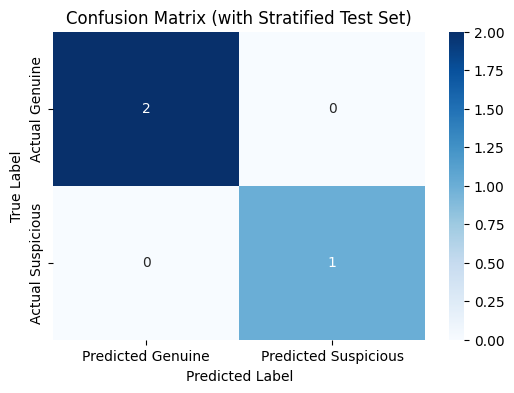

In [35]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Re-train and re-predict with the stratified split
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Generate a new confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Genuine', 'Predicted Suspicious'],
            yticklabels=['Actual Genuine', 'Actual Suspicious'])
plt.title('Confusion Matrix (with Stratified Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [36]:
from sklearn.metrics import classification_report
print('Classification Report (with Stratified Test Set):\n', classification_report(y_test, y_pred))

Classification Report (with Stratified Test Set):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



### Cross-Validation Scores

To get a more robust estimate of the model's performance and assess its generalization ability, let's perform cross-validation. This will run the training and evaluation process multiple times on different subsets of the data.

In [50]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Instantiate the classifier (using the same parameters as before)
cv_clf = RandomForestClassifier(n_estimators=100, random_state=42)

# Define StratifiedKFold
# n_splits is set to 5, which is the same as before. If the least populated class
# has fewer than n_splits, you might need to reduce n_splits or collect more data.
# In your case, the least populated class has 4 members, so n_splits=5 will still
# trigger a warning with StratifiedKFold, but it's the correct approach.
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Perform 5-fold cross-validation
cv_scores = cross_val_score(cv_clf, X, y, cv=skf, scoring='accuracy')

print(f"Cross-validation scores (accuracy): {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Cross-validation scores (accuracy): [1.         0.66666667 1.        ]
Mean cross-validation accuracy: 0.8889
Standard deviation of cross-validation accuracy: 0.1571


In [37]:
# Get the indices of the test set
test_indices = X_test.index

# Create a DataFrame for y_test and y_pred for easy comparison
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred}, index=test_indices)

# Identify False Positives: Actual is 0 (Genuine) but Predicted is 1 (Suspicious)
false_positives = comparison_df[(comparison_df['Actual'] == 0) & (comparison_df['Predicted'] == 1)]

if not false_positives.empty:
    print('False Positives (Actual Genuine, Predicted Suspicious):')
    # Display the original data for these false positives
    display(df.loc[false_positives.index])
else:
    print('No False Positives found in the test set.')

No False Positives found in the test set.


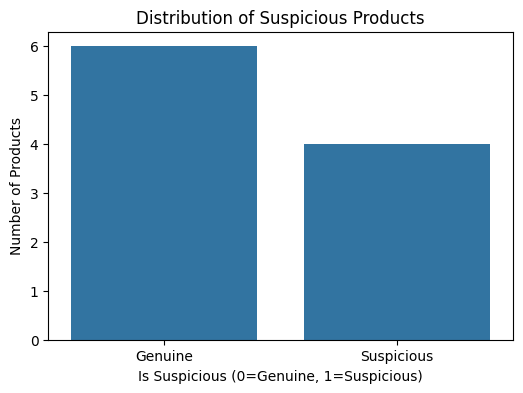

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='is_suspicious', data=df)
plt.title('Distribution of Suspicious Products')
plt.xlabel('Is Suspicious (0=Genuine, 1=Suspicious)')
plt.ylabel('Number of Products')
plt.xticks([0, 1], ['Genuine', 'Suspicious'])
plt.show()

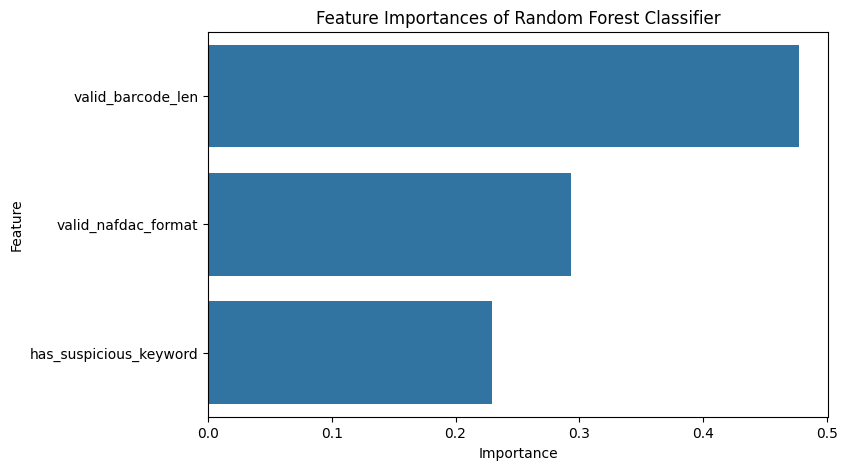

In [39]:
importances = clf.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances of Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

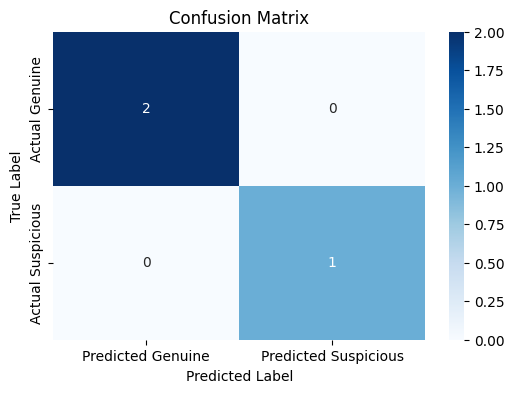

In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Genuine', 'Predicted Suspicious'],
            yticklabels=['Actual Genuine', 'Actual Suspicious'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

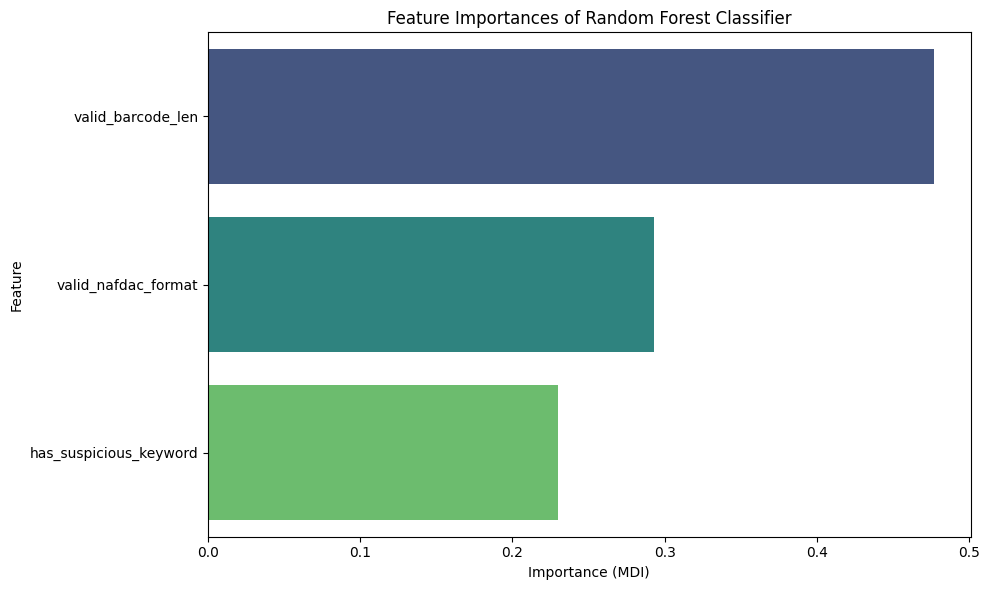

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure feature_importance_df is sorted for better visualization
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=feature_importance_df, palette='viridis', legend=False)
plt.title('Feature Importances of Random Forest Classifier')
plt.xlabel('Importance (MDI)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [41]:
print('''
fake-drug-detector/
│── data/
│   └── drug_sample_dataset.csv
│── models/
│   └── classifier.pkl
│── notebooks/
│   └── Fake_Drug_Checker.ipynb
│── README.md
│── requirements.txt
''')


fake-drug-detector/
│── data/
│   └── drug_sample_dataset.csv
│── models/
│   └── classifier.pkl
│── notebooks/
│   └── Fake_Drug_Checker.ipynb
│── README.md
│── requirements.txt



In [42]:
import pandas as pd

# Assuming the dataset is located in the 'fake-drug-detector/data/' directory
# This path is relative to the root of the Colab environment.
# IMPORTANT: Update this path to the actual location of your file in Google Drive
file_path = 'https://docs.google.com/spreadsheets/d/10j5Z355NcIHKMxTyaS_hZcCMQcF-bEbsUXyOFI_pOnE/edit?usp=drivesdkv' # e.g., '/content/drive/MyDrive/my_datasets/drug_sample_dataset.csv'

try:
    df_drug_sample = pd.read_csv(file_path)
    print(f'Successfully loaded data from {file_path}')
    display(df_drug_sample.head())
except FileNotFoundError:
    print(f'Error: The file was not found at {file_path}. Please ensure the file is in the correct location and try again.')
except Exception as e:
    print(f'An error occurred: {e}')

An error occurred: HTTP Error 401: Unauthorized


In [43]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")

In [44]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [45]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

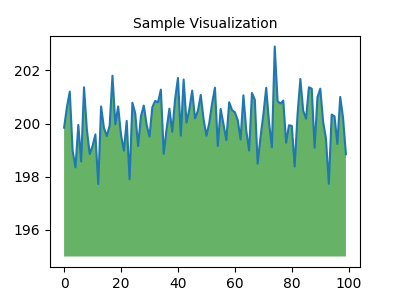

In [46]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [Train a CNN to classify handwritten digits on the MNIST dataset using Flax NNX API](https://colab.research.google.com/github/google/flax/blob/main/docs_nnx/mnist_tutorial.ipynb)
- [Train a Vision Transformer (ViT) for image classification with JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_Vision_transformer.ipynb)
- [Text classification with a transformer language model using JAX](https://colab.research.google.com/github/jax-ml/jax-ai-stack/blob/main/docs/source/JAX_transformer_text_classification.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Train a miniGPT language model with JAX AI Stack](https://docs.jaxstack.ai/en/latest/JAX_for_LLM_pretraining.html)
- [LoRA/QLoRA finetuning for LLM using Tunix](https://github.com/google/tunix/blob/main/examples/qlora_gemma.ipynb)
- [Parameter-efficient fine-tuning of Gemma with LoRA and QLoRA](https://keras.io/examples/keras_recipes/parameter_efficient_finetuning_of_gemma_with_lora_and_qlora/)
- [Loading Hugging Face Transformers Checkpoints](https://keras.io/keras_hub/guides/hugging_face_keras_integration/)
- [8-bit Integer Quantization in Keras](https://keras.io/guides/int8_quantization_in_keras/)
- [Float8 training and inference with a simple Transformer model](https://keras.io/examples/keras_recipes/float8_training_and_inference_with_transformer/)
- [Pretraining a Transformer from scratch with KerasHub](https://keras.io/keras_hub/guides/transformer_pretraining/)
- [Simple MNIST convnet](https://keras.io/examples/vision/mnist_convnet/)
- [Image classification from scratch using Keras 3](https://keras.io/examples/vision/image_classification_from_scratch/)
- [Image Classification with KerasHub](https://keras.io/keras_hub/guides/classification_with_keras_hub/)
